"""
rc_plot.py — Step 2: Plot from rc_papers.csv
=============================================
Produces TWO figures:
  1. rc_landscape.png            — absolute publication counts
  2. rc_landscape_normalized.png — fractional / 100% stacked

Landmark ★ markers are placed INSIDE their subfield band,
vertically centred on the band at the paper's year.
Annotations point upward above the total stack to avoid overlap.

pip install matplotlib numpy
python rc_plot.py
"""

In [1]:
import csv, re, sys
from collections import defaultdict
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

1. Config

In [3]:
INPUT_CSV    = "rc_papers.csv"
LANDMARK_CSV = "rc_landmark_papers.csv"
OUTPUT_ABS   = "rc_landscape.png"
OUTPUT_NORM  = "rc_landscape_normalized.png"
YEARS        = (2001, 2026)

SUBFIELD_COLORS = {
    "Photonics & Optics":           "#f4a261",
    "Physical & Hardware RC":       "#e76f51",
    "Quantum RC":                   "#9b5de5",
    "Nonlinear Dynamics & Chaos":   "#2a9d8f",
    "Neuroscience & Comp. Neuro":   "#457b9d",
    "Mathematics & Theory":         "#1d3557",
    "Signal Processing & Comms":    "#606c38",
    "Control & Robotics":           "#bc6c25",
    "Climate & Earth Sciences":     "#52b788",
    "ML / Next-Gen RC":             "#e9c46a",
    "General RC / ESN Methods":     "#a8dadc",
    "Other / Interdisciplinary":    "#888888",
}
SUBFIELD_ORDER = list(SUBFIELD_COLORS.keys())

4. Helper funcss

In [28]:
def load_csv(path, required=True):
    try:
        with open(path, newline="", encoding="utf-8") as f:
            return list(csv.DictReader(f))
    except FileNotFoundError:
        if required:
            print(f"ERROR: '{path}' not found."); sys.exit(1)
        return []


def norm_title(t):
    return re.sub(r"[^a-z0-9]", "", (t or "").lower())[:60]


def load_landmarks(papers, landmark_csv):
    """
    Match landmark CSV rows against harvested papers by normalised title.
    Unmatched rows (tech reports not in OpenAlex) are injected directly.
    Falls back to 'landmark' column in rc_papers.csv if no separate file.
    """
    lm_rows = load_csv(landmark_csv, required=False)

    if not lm_rows:
        print(f"  No '{landmark_csv}' — using 'landmark' column in rc_papers.csv")
        return [p for p in papers if p.get("landmark", "").strip()]

    index = {norm_title(p.get("title", "")): p for p in papers}
    matched, unmatched = [], []

    for row in lm_rows:
        key = norm_title(row.get("title", ""))
        if key in index:
            p = index[key]
            p["landmark"]           = row.get("landmark", "")
            p["landmark_subfield"]  = row.get("subfield", p.get("subfield", ""))
            matched.append(p)
        else:
            unmatched.append({
                "title":            row.get("title", ""),
                "year":             row.get("year", ""),
                "citationCount":    9999,
                "cites_per_year":   999,
                "subfield":         row.get("subfield", "General RC / ESN Methods"),
                "landmark":         row.get("landmark", ""),
                "landmark_subfield":row.get("subfield", "General RC / ESN Methods"),
            })

    print(f"  Matched  : {len(matched)}")
    if unmatched:
        print(f"  Injected : {len(unmatched)}  (not in harvested dataset)")
        for u in unmatched:
            print(f"    {u['year']}  {u['title'][:60]}")

    return matched + unmatched

# ══════════════════════════════════════════════════════════════════════
# DATA MATRIX
# ══════════════════════════════════════════════════════════════════════

def build_matrix(papers, order, years):
    counts = {sf: defaultdict(int) for sf in order}
    for p in papers:
        y  = p.get("year")
        sf = (p.get("subfield") or "").strip() or "Other / Interdisciplinary"
        try: y = int(y)
        except (TypeError, ValueError): continue
        if YEARS[0] <= y <= YEARS[1]:
            counts[sf][y] += 1
    return np.array([[counts[sf].get(y, 0) for y in years]
                     for sf in order], dtype=float)

# ══════════════════════════════════════════════════════════════════════
# LANDMARK PLACEMENT — inside subfield band, annotations above stack
# ══════════════════════════════════════════════════════════════════════

def place_landmarks(ax, landmarks, order, matrix, years, totals, normalised):
    """
    For each landmark:
      - compute the y-midpoint of its subfield band at that year
      - draw a white ★ with a coloured edge matching the subfield
      - draw a short annotation box above the top of the stack
    """
    col_total = np.where(totals > 0, totals, 1.0)

    # group landmarks by (subfield, year) to handle vertical stacking
    groups = defaultdict(list)
    for p in landmarks:
        try: yr = int(p.get("year"))
        except (TypeError, ValueError): continue
        if not (YEARS[0] <= yr <= YEARS[1]): continue
        sf = (p.get("landmark_subfield") or p.get("subfield") or
              "General RC / ESN Methods")
        groups[(sf, yr)].append(p)

    # we need a y-offset per year to stagger annotation boxes horizontally
    ann_yr_count = defaultdict(int)

    for (sf, yr), group in sorted(groups.items(),
                                   key=lambda kv: kv[0][1]):
        idx = yr - years[0]
        if idx < 0 or idx >= matrix.shape[1]:
            continue

        # ── compute band bottom and top ───────────────────────────────
        bottom = 0.0
        band_b = band_t = None
        for i, s in enumerate(order):
            h = matrix[i, idx] / col_total[idx] if normalised else matrix[i, idx]
            if s == sf:
                band_b = bottom
                band_t = bottom + h
                break
            bottom += h

        if band_b is None or (band_t - band_b) < 1e-6:
            continue   # subfield absent this year

        band_h   = band_t - band_b
        n_in_grp = len(group)
        sf_color = SUBFIELD_COLORS.get(sf, "#FFD700")

        stack_top = (totals[idx] / col_total[idx]) if normalised else totals[idx]

        for k, p in enumerate(sorted(group,
                                     key=lambda x: -(float(x.get("cites_per_year") or 0)))):
            # vertical position inside band: evenly distribute
            frac  = (k + 0.5) / n_in_grp
            ystar = band_b + frac * band_h

            # ── star marker ───────────────────────────────────────────
            ax.plot(yr, ystar, marker="*", color="black",
                    markersize=12, zorder=12,
                    markeredgecolor=sf_color, markeredgewidth=0.8)

            # ── annotation above the stack ────────────────────────────
            # stagger horizontally to avoid overlap for same-year landmarks
            ann_n = ann_yr_count[yr]
            ann_yr_count[yr] += 1

            if normalised:
                ann_y   = min(0.98, ystar + 0.05 + ann_n * 0.03)
                x_shift = 0.15 + ann_n * 0.4
            else:
                headroom = stack_top * 0.06
                ann_y    = stack_top + headroom + ann_n * stack_top * 0.08
                x_shift  = 0.15 + ann_n * 0.5

            title_s = (p.get("title") or "")[:36]
            reason  = (p.get("landmark") or "").strip()[:40]

            ax.annotate(
                f"{title_s}\n{reason}",
                xy=(yr, ystar),
                xytext=(yr + x_shift, ann_y),
                fontsize=7.5, color=sf_color, alpha=0.95, zorder=13,
                va="bottom", ha="left",
                arrowprops=dict(arrowstyle="-", color=sf_color,
                                alpha=0.45, lw=0.55,
                                connectionstyle="arc3,rad=0.1"),
                bbox=dict(boxstyle="round,pad=0.22", fc="white",
                          ec=sf_color, alpha=0.85, lw=0.6),
            )

# ══════════════════════════════════════════════════════════════════════
# BAND LABELS (right edge)
# ══════════════════════════════════════════════════════════════════════

def draw_band_labels(ax, order, matrix, totals, years, normalised):
    col_total = np.where(totals > 0, totals, 1.0)
    cum = np.zeros(matrix.shape[1])
    for i, sf in enumerate(order):
        heights = matrix[i] / col_total if normalised else matrix[i]
        mid_y   = cum[-1] + heights[-1] / 2.0
        thresh  = 0.03 if normalised else totals[-1] * 0.03
        if matrix[i].sum() > 0 and heights[-1] > thresh:
            ax.text(years[-1] + 0.3, mid_y, sf,
                    fontsize=24, color="black", va="center", alpha=0.9)
        cum += heights

# ══════════════════════════════════════════════════════════════════════
# SHARED STYLE
# ══════════════════════════════════════════════════════════════════════

def _style(ax):
    ax.tick_params(colors="black", labelsize=12)
    ax.set_xticks(range(YEARS[0], YEARS[1] + 1, 2))
    for spine in ax.spines.values():
        spine.set_edgecolor("#666")
    ax.yaxis.grid(True, color="#d0d0d0", lw=0.5, zorder=0)
    ax.set_axisbelow(True)


def _legend(ax, order, matrix, totals, normalised):
    thresh = 0.03 if normalised else (totals[-1] * 0.03 if totals[-1] else 0)
    handles = [
        mpatches.Patch(color=SUBFIELD_COLORS.get(sf, "#aaa"),
                       label=sf, alpha=0.88)
        for i, sf in enumerate(order)
        if matrix[i].sum() > 0 and matrix[i, -1] <= thresh
    ]
    handles.append(
        plt.Line2D([0], [0], marker="*", color="black", markersize=12,
                   lw=0, markeredgecolor="#FFD700", markeredgewidth=0.8,
                   label="Landmark (in band)"),
    )
    ax.legend(handles=handles, loc="upper left", fontsize=11,
              framealpha=0.85, facecolor="white", edgecolor="#999",
              ncol=1, labelcolor="black", borderpad=0.8)

# ══════════════════════════════════════════════════════════════════════
# FIGURE 1 — ABSOLUTE
# ══════════════════════════════════════════════════════════════════════

def plot_absolute(papers, landmarks, order, matrix, years, totals):
    fig, ax = plt.subplots(figsize=(24, 12))

    colors = [SUBFIELD_COLORS.get(sf, "#aaaaaa") for sf in order]
    ax.stackplot(years, matrix, colors=colors, alpha=0.88, linewidth=0)
    ax.plot(years, totals, color="black", lw=1.8,
            linestyle="--", alpha=0.5, zorder=5)

    draw_band_labels(ax, order, matrix, totals, years, normalised=False)
    place_landmarks(ax, landmarks, order, matrix, years, totals,
                    normalised=False)

    # fixed origin annotations
    mid = float(np.mean(totals[1:5])) if len(totals) > 4 else 10.0
    ax.annotate("ESN (Jaeger 2001)\n+ LSM (Maass 2002)",
                xy=(2001.8, 3), xytext=(2003.5, mid * 0.6 + 8),
                fontsize=12, color="black", fontweight="bold",
                arrowprops=dict(arrowstyle="->", color="black", lw=1.1),
                bbox=dict(boxstyle="round", fc="white", ec="black", alpha=0.85))

    ymax = float(totals.max()) * 1.7 if totals.max() > 0 else 100
    ax.set_xlim(YEARS[0] - 0.5, YEARS[1] + 4.0)
    ax.set_ylim(0, ymax)
    ax.set_xlabel("Year", color="black", fontsize=18, labelpad=10)
    ax.set_ylabel("Publications per Year", color="black", fontsize=18, labelpad=10)
    _style(ax)
    _legend(ax, order, matrix, totals, normalised=False)

    plt.tight_layout()
    plt.savefig(OUTPUT_ABS, dpi=200, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print(f"Saved -> '{OUTPUT_ABS}'")
    plt.show()

# ══════════════════════════════════════════════════════════════════════
# FIGURE 2 — NORMALISED
# ══════════════════════════════════════════════════════════════════════

def plot_normalised(papers, landmarks, order, matrix, years, totals):
    fig, ax = plt.subplots(figsize=(24, 18))

    col_total   = np.where(totals > 0, totals, 1.0)
    norm_matrix = matrix / col_total

    colors = [SUBFIELD_COLORS.get(sf, "#aaaaaa") for sf in order]
    ax.stackplot(years, norm_matrix, colors=colors, alpha=0.88, linewidth=0)

    draw_band_labels(ax, order, matrix, totals, years, normalised=True)
    place_landmarks(ax, landmarks, order, matrix, years, totals,
                    normalised=True)

    ax.set_yticks(np.linspace(0.0, 1.0, 6))
    ax.set_yticklabels([f"{v:.1f}" for v in np.linspace(0.0, 1.0, 6)])

    ax.set_xlim(YEARS[0] - 0.5, YEARS[1] + 4.0)
    ax.set_ylim(0, 1.0)
    ax.set_xlabel("Year", color="black", fontsize=24, labelpad=10)
    ax.set_ylabel("Fraction of Publications", color="black", fontsize=24, labelpad=10)
    _style(ax)
    ###increase legend font size
    _legend(ax, order, norm_matrix, norm_matrix.sum(axis=0), normalised=True)
    leg = ax.get_legend()
    if leg is not None:
        for txt in leg.get_texts():
            txt.set_fontsize(18)

    plt.tight_layout()
    plt.savefig(OUTPUT_NORM, dpi=200, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print(f"Saved -> '{OUTPUT_NORM}'")
    plt.show()


7,810 papers loaded from 'rc_papers.csv'

Loading landmarks from 'rc_landmark_papers.csv'...
  Matched  : 20
  Injected : 4  (not in harvested dataset)
    2001  The echo state approach to analysing and training recurrent 
    2004  Edge of chaos and prediction of computational performance fo
    2013  Parallel photonic information processing at gigabyte per sec
    2014  Separation of variables and universality in reservoir comput
Total landmarks : 24

── Subfield breakdown ──
  Photonics & Optics                             1227  ██████████████████
  Physical & Hardware RC                         1231  ██████████████████
  Quantum RC                                      217  ███
  Nonlinear Dynamics & Chaos                     1029  ███████████████
  Neuroscience & Comp. Neuro                      257  ███
  Mathematics & Theory                            157  ██
  Signal Processing & Comms                       271  ████
  Control & Robotics                              224  ███
  

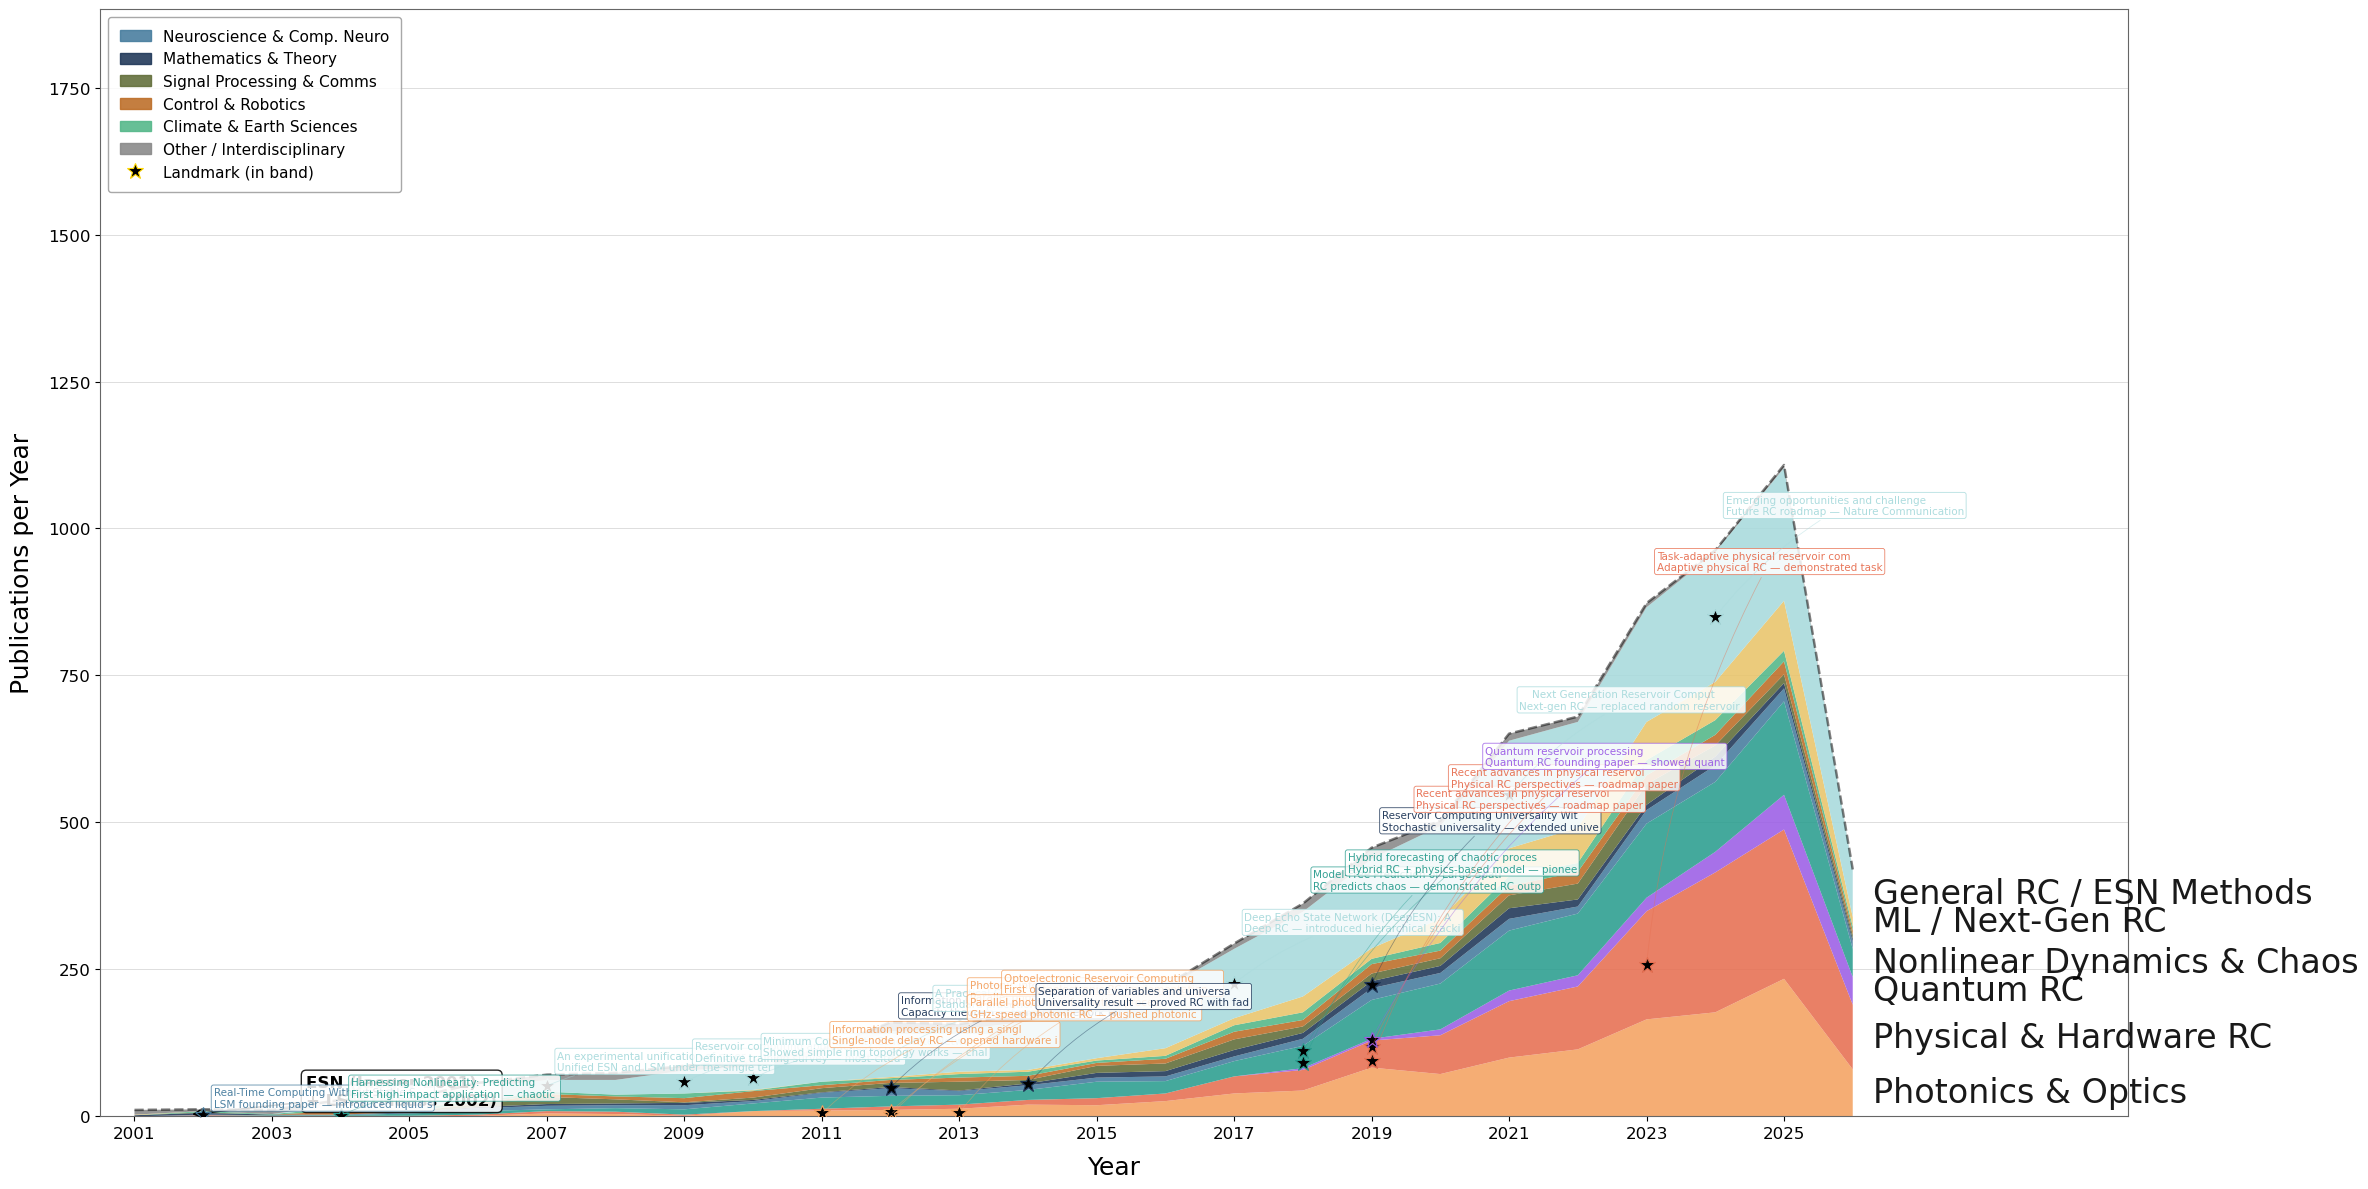


Plotting normalised figure...
Saved -> 'rc_landscape_normalized.png'


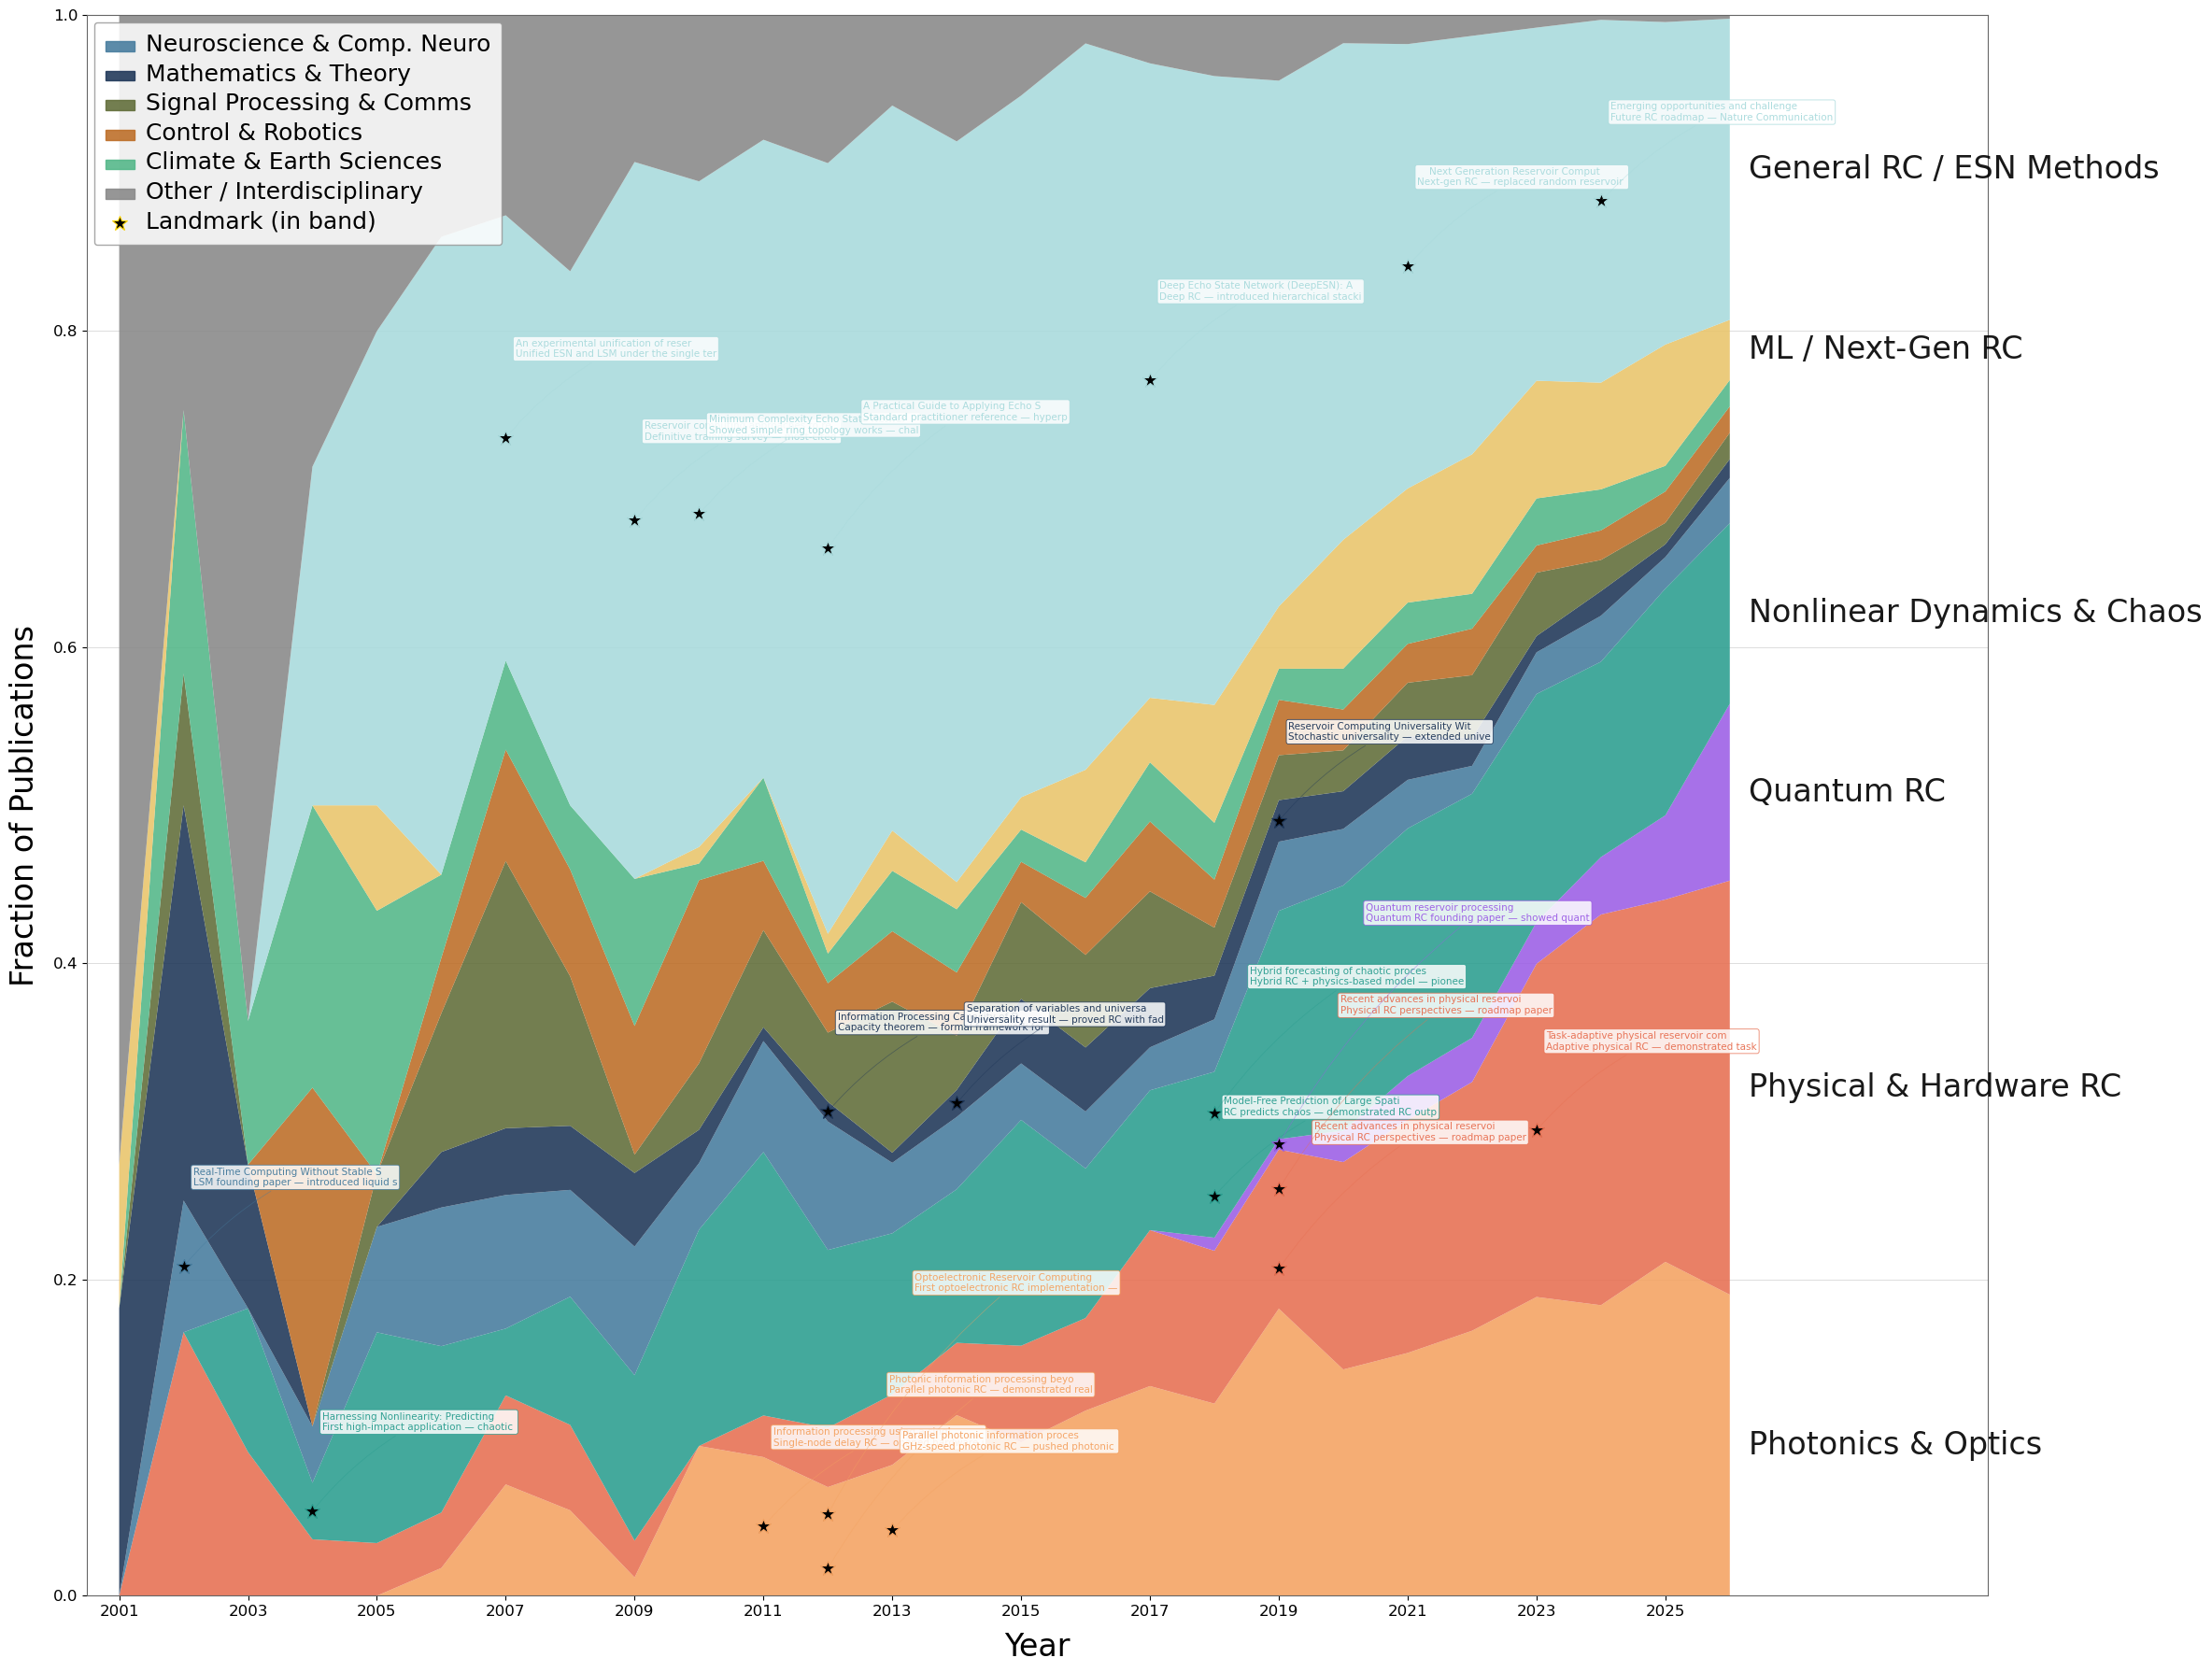

In [29]:
papers = load_csv(INPUT_CSV)
print(f"\n{len(papers):,} papers loaded from '{INPUT_CSV}'")

print(f"\nLoading landmarks from '{LANDMARK_CSV}'...")
landmarks = load_landmarks(papers, LANDMARK_CSV)
print(f"Total landmarks : {len(landmarks)}\n")

# extend order with any unknown subfields in CSV
all_sf = set(p.get("subfield", "") for p in papers)
order  = SUBFIELD_ORDER + sorted(
    sf for sf in all_sf if sf not in SUBFIELD_ORDER and sf)

years  = list(range(YEARS[0], YEARS[1] + 1))
matrix = build_matrix(papers, order, years)
totals = matrix.sum(axis=0)

print("── Subfield breakdown ──")
row_sums = matrix.sum(axis=1)
mx = row_sums.max() or 1
for i, sf in enumerate(order):
    n = int(row_sums[i])
    if n > 0:
        print(f"  {sf:<45} {n:>5}  {'█'*(n*35//int(mx))}")

print("\nPlotting absolute figure...")
plot_absolute(papers, landmarks, order, matrix, years, totals)

print("\nPlotting normalised figure...")
plot_normalised(papers, landmarks, order, matrix, years, totals)